# Step 1 — Black-Scholes Closed Form

We implement the exact analytical formulas for European call and put prices.
These will serve as the ground truth when validating the FDM solvers later.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.core import bs_price

## Parameters

In [2]:
K     = 100
r     = 0.05
sigma = 0.20
T     = 1.0
S_max = 3 * K

## 1. Price vs Stock Price

Sweep S from 0 to S_max and compute call and put prices at each point.

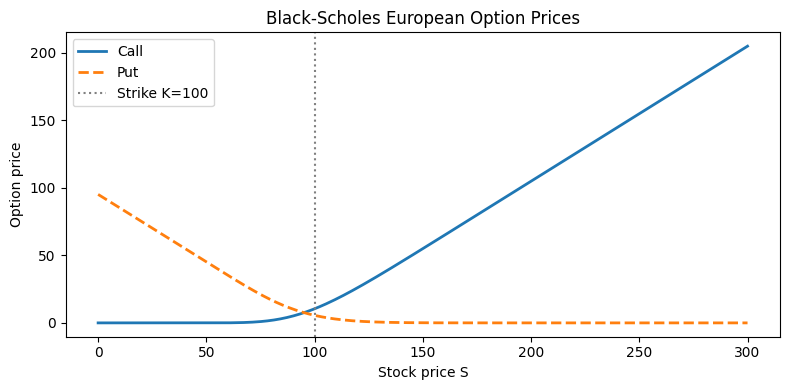

In [3]:
S = np.linspace(0, S_max, 300)

call_prices = np.array([bs_price(s, K, T, r, sigma, option_type="call") for s in S])
put_prices  = np.array([bs_price(s, K, T, r, sigma, option_type="put")  for s in S])

plt.figure(figsize=(8, 4))
plt.plot(S, call_prices, label='Call', lw=2)
plt.plot(S, put_prices,  label='Put',  lw=2, ls='--')
plt.axvline(K, color='grey', ls=':', label=f'Strike K={K}')
plt.xlabel('Stock price S')
plt.ylabel('Option price')
plt.title('Black-Scholes European Option Prices')
plt.legend()
plt.tight_layout()
plt.show()